## 4.2 내결함성 양자 컴퓨팅 (Fault-Tolerant Quantum Computing)

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 3큐비트 반복 부호를 위한 양자 회로 초기화
qc = QuantumCircuit(5, 2)

In [3]:
# 1단계: 논리 큐비트를 3개의 물리 큐비트로 인코딩
qc.h(0)  # |+> 상태 준비
qc.cx(0, 1)
qc.cx(0, 2)

In [4]:
# 2단계: (시연을 위해) 오류 주입
qc.x(1)  # 큐비트 1에 비트 반전 오류

In [5]:
# 3단계: 신드롬 측정 (오류 검출)
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.measure([3, 4], [0, 1])

In [6]:
# 4단계: 신드롬 측정에 기반한 오류 정정
# 호환성 수정(qiskit 2.x): Instruction.c_if 제거 → with qc.if_test(...) 블록 사용
with qc.if_test((qc.clbits[0], 1)):
    qc.x(1)  # 큐비트 1의 비트 반전 정정
with qc.if_test((qc.clbits[1], 1)):
    qc.x(2)  # 큐비트 2의 비트 반전 정정

In [7]:
# 5단계: 논리 큐비트 디코딩
qc.cx(0, 1)
qc.cx(0, 2)
qc.ccx(1, 2, 0)  # 다수결 투표

In [8]:
# 6단계: 최종 상태 측정
qc.measure_all()

In [9]:
# AerSimulator로 회로 시뮬레이션
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()

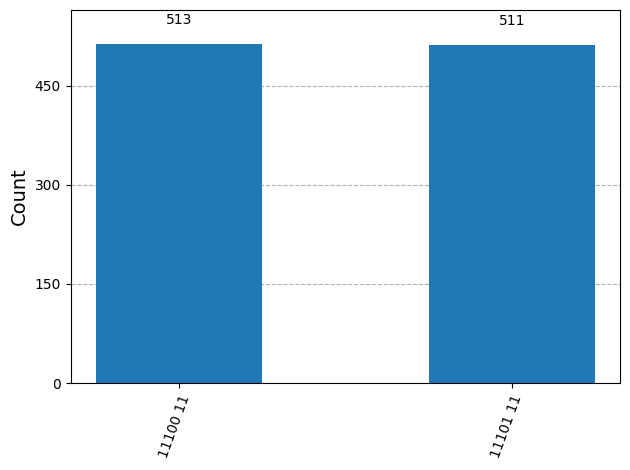

In [10]:
# 결과 추출 및 그리기
counts = result.get_counts()
plot_histogram(counts)
plt.show()

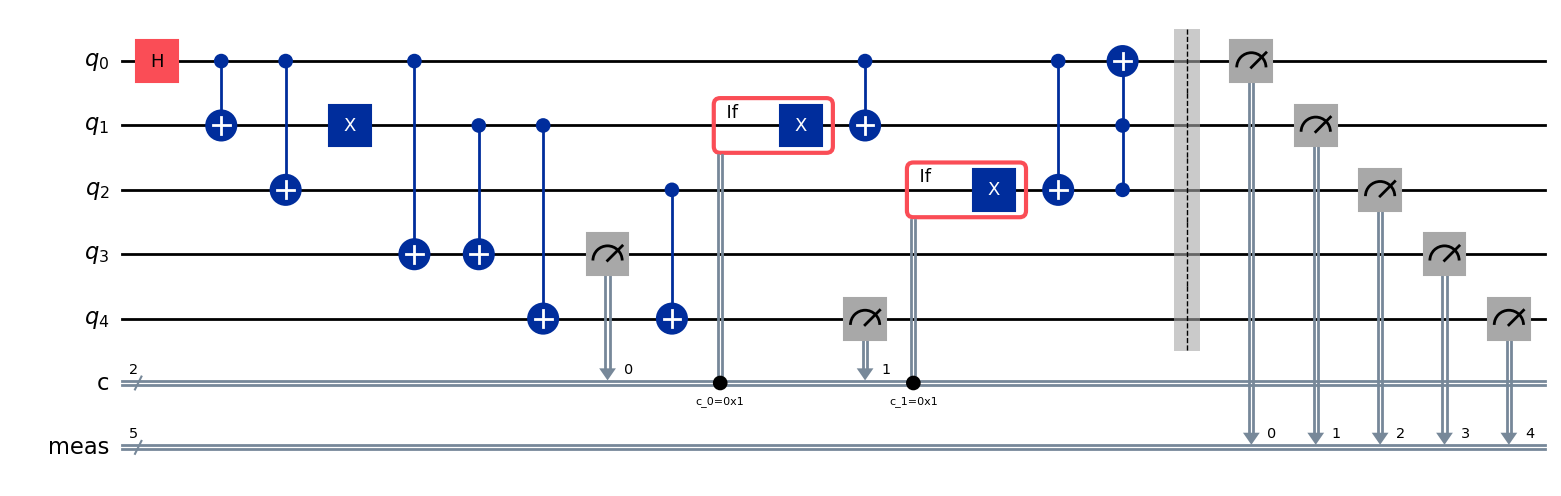

In [11]:
# 양자 회로 표시
qc.draw('mpl')
plt.show()